### Importing necessary libraries

In [131]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import os

### Importing the dataset

In [133]:
data=pd.read_csv("E:/a/sales_full_data.csv")

In [134]:
data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04-07-19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04-12-19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04-12-19 14:38,"669 Spruce St, Los Angeles, CA 90001"


### Checking Null values and droping them

In [135]:
data.isna().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [136]:
data.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [137]:
data.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [138]:
data=data.dropna()

In [139]:
data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04-07-19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04-12-19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04-12-19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


### Changing data types and Adding new columns

In [140]:
data['Quantity Ordered']=pd.to_numeric(data['Quantity Ordered'],errors='coerce')
data['Order ID']=pd.to_numeric(data['Order ID'],errors='coerce')
data['Price Each']=pd.to_numeric(data['Price Each'],errors='coerce')
data['Order Date']=pd.to_datetime(data['Order Date'],errors='coerce')
data['Month']=data['Order Date'].dt.month
data['Year']=data['Order Date'].dt.year
data['day']=data['Order Date'].dt.day
data['Hour']=data['Order Date'].dt.hour

In [141]:
data['sales']= data['Quantity Ordered']*data['Price Each']

In [142]:
data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Year,day,Hour,sales
0,176558.0,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4.0,2019.0,19.0,8.0,23.90
2,176559.0,Bose SoundSport Headphones,1.0,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4.0,2019.0,7.0,22.0,99.99
3,176560.0,Google Phone,1.0,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,2019.0,12.0,14.0,600.00
4,176560.0,Wired Headphones,1.0,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,2019.0,12.0,14.0,11.99
5,176561.0,Wired Headphones,1.0,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4.0,2019.0,30.0,9.0,11.99


### Question 1 : Which month had the highest and lowest sales? What do you think the reason was?


In [143]:
temp=data['Month'].value_counts()
print(temp)

12.0    24984
10.0    20282
4.0     18279
11.0    17573
5.0     16566
3.0     15153
7.0     14293
6.0     13554
2.0     11975
8.0     11961
9.0     11621
1.0      9709
Name: Month, dtype: int64


In [144]:
res=data.groupby('Month').sum()
res

,Order ID,Quantity Ordered,Price Each,Year,day,Hour,sales
Month,,,,,,,
1.0,1.421631e+09,10903.0,1.811768e+06,19602505.0,155814.0,139485.0,1.822257e+06
2.0,1.871053e+09,13449.0,2.188885e+06,24177525.0,174408.0,172669.0,2.202022e+06
3.0,2.564811e+09,17005.0,2.791208e+06,30593907.0,241774.0,218969.0,2.807100e+06
4.0,3.387347e+09,20558.0,3.367671e+06,36905301.0,282960.0,262259.0,3.390670e+06
5.0,3.345872e+09,18667.0,3.135125e+06,33446754.0,264875.0,238780.0,3.152607e+06
6.0,2.932976e+09,15253.0,2.562026e+06,27365526.0,209880.0,195528.0,2.577802e+06
7.0,3.284140e+09,16072.0,2.632540e+06,28857567.0,227910.0,206169.0,2.647776e+06
8.0,2.899374e+09,13448.0,2.230345e+06,24149259.0,192315.0,172289.0,2.244468e+06
9.0,2.948727e+09,13109.0,2.084992e+06,23462799.0,180101.0,168513.0,2.097560e+06


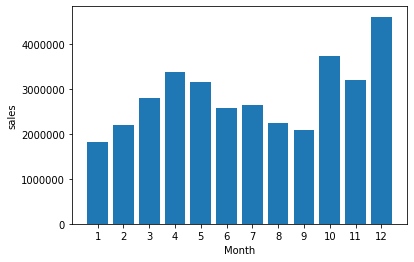

In [145]:
month=range(1,13)
plt.bar(month,res['sales'])
plt.xticks(month)
plt.xlabel('Month')
plt.ylabel('sales')
plt.show()


### Answer: The 12th month had the highest sales and the 1st month had the lowest sales and the reason for the sales in the 12th month will be the christmas and the lowest sales in the 1st month will be because most of the people just spent their money buying gifts for christmas.

In [146]:
time=data['Hour'].value_counts()
time

19.0    12905
12.0    12587
11.0    12411
18.0    12280
20.0    12228
13.0    12129
14.0    10984
10.0    10944
21.0    10921
17.0    10899
16.0    10384
15.0    10175
22.0     8822
9.0      8748
23.0     6275
8.0      6256
7.0      4011
0.0      3910
6.0      2482
1.0      2350
5.0      1321
2.0      1243
4.0       854
3.0       831
Name: Hour, dtype: int64

In [147]:
x=data.groupby('Hour').sum()
x

,Order ID,Quantity Ordered,Price Each,Month,Year,day,sales
Hour,,,,,,,
0.0,9.009579e+08,4428.0,709296.70,27554.0,7894302.0,62015.0,713721.27
1.0,5.432331e+08,2619.0,458490.00,16657.0,4744659.0,37333.0,460866.88
2.0,2.824069e+08,1398.0,233833.64,8507.0,2509621.0,19631.0,234851.44
3.0,1.922044e+08,928.0,144726.42,5904.0,1677792.0,13430.0,145757.89
4.0,1.992037e+08,937.0,162058.18,6148.0,1724230.0,13756.0,162661.01
5.0,3.044691e+08,1493.0,229621.21,9301.0,2667101.0,21347.0,230679.82
6.0,5.721289e+08,2810.0,445000.11,17539.0,5011158.0,39824.0,448113.00
7.0,9.320453e+08,4556.0,740568.11,28850.0,8098209.0,63111.0,744854.12
8.0,1.434065e+09,7002.0,1185970.62,43626.0,12630864.0,98078.0,1192348.97


Text(0, 0.5, 'Sales')

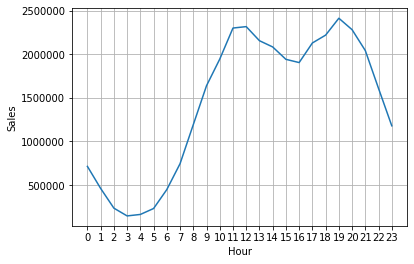

In [148]:
hour=range(0,24)
plt.plot(hour,x['sales'])
plt.xticks(hour)
plt.grid()
plt.xlabel('Hour')
plt.ylabel('Sales')

### Answer: At 11am and at 6pm are the best time to display ads

### Question 3 : What products were sold the most?

In [225]:
product_group=data.groupby(['Product']).sum().reset_index()


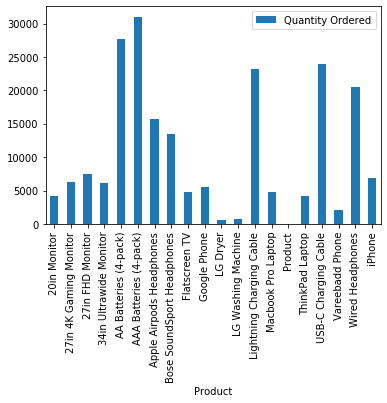

In [226]:
product_group.plot("Product","Quantity Ordered",kind='bar')


### ANSWER : The most sold product was " AAA batteries(4-pack)